**Stochastic Modeling**

**Importing Libraries**

In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import quad
from scipy.optimize import minimize
import matplotlib.pyplot as plt

**Loading and Preparation of Market Data Provided**

In [12]:
df = pd.read_excel('/content/MScFE 622_Stochastic Modeling_GWP1_Option data (1).xlsx')
df = df.sort_values(by=["Days to maturity", "Strike"]).reset_index(drop=True)
df

,Days to maturity,Strike,Price,Type
0,15,227.5,10.520000,C
1,15,227.5,4.320000,P
2,15,230.0,10.050000,C
3,15,230.0,5.200000,P
4,15,232.5,7.750000,C
5,15,232.5,6.450000,P
6,15,235.0,6.010000,C
7,15,235.0,7.560000,P
8,15,237.5,4.750000,C
9,15,237.5,8.780000,P


In [15]:
# Model constants
S0 = 232.90
r = 0.015
trading_days = 250
T = 15 / trading_days

# Converting maturity to years
df["T"] = df["Days to maturity"] / trading_days
df_15 = df[df['Days to maturity'] == 15]

df_15

,Days to maturity,Strike,Price,Type,T
0,15,227.5,10.52,C,0.06
1,15,227.5,4.32,P,0.06
2,15,230.0,10.05,C,0.06
3,15,230.0,5.20,P,0.06
4,15,232.5,7.75,C,0.06
5,15,232.5,6.45,P,0.06
6,15,235.0,6.01,C,0.06
7,15,235.0,7.56,P,0.06
8,15,237.5,4.75,C,0.06
9,15,237.5,8.78,P,0.06


**Heston Characteristic Function**

In [ ]:
def H93_char_func(u, T, r, kappa_v, theta_v, sigma_v, rho, v0):
    c1 = kappa_v * theta_v
    c2 = -np.sqrt(
        (rho * sigma_v * u * 1j - kappa_v) ** 2 - sigma_v**2 * (-u * 1j - u**2)
    )
    c3 = (kappa_v - rho * sigma_v * u * 1j + c2) / (
        kappa_v - rho * sigma_v * u * 1j - c2
    )
    H1 = r * u * 1j * T + (c1 / sigma_v**2) * (
        (kappa_v - rho * sigma_v * u * 1j + c2) * T
        - 2 * np.log((1 - c3 * np.exp(c2 * T)) / (1 - c3))
    )
    H2 = (
        (kappa_v - rho * sigma_v * u * 1j + c2)
        / sigma_v**2
        * ((1 - np.exp(c2 * T)) / (1 - c3 * np.exp(c2 * T)))
    )
    char_func_value = np.exp(H1 + H2 * v0)
    return char_func_value

In [ ]:
def H93_int_func(u, S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0):
    char_func_value = H93_char_func(
        u - 1j * 0.5, T, r, kappa_v, theta_v, sigma_v, rho, v0
    )
    int_func_value = (
        1 / (u**2 + 0.25) * (np.exp(1j * u * np.log(S0 / K)) * char_func_value).real
    )
    return int_func_value

**Lewis (2001) European call pricing function**

In [ ]:
def H93_call_value(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0):
    int_value = quad(
        lambda u: H93_int_func(u, S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0),
        0,
        np.inf,
        limit=250,
    )[0]
    call_value = max(0, S0 - np.exp(-r * T) * np.sqrt(S0 * K) / np.pi * int_value)
    return call_value

**Put Price via Parity**

In [ ]:
def H93_put_value(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0):
    call = H93_call_value(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0)
    put = call - S0 + K * np.exp(-r * T)
    return put

**Objective function (MSE)**

In [ ]:
def calibration_error(params, df, S0, T, r):
    kappa_v, theta_v, sigma_v, rho, v0 = params
    if theta_v < 0 or v0 < 0 or kappa_v < 0 or sigma_v < 0 or rho <= -1 or rho >= 1:
        return 1e6  # large penalty for invalid params
    error = 0.0
    for i, row in df.iterrows():
        K = row['Strike']
        market = row['Price']
        if row['Type'] == 'C':
            model = H93_call_value(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0)
        else:
            model = H93_put_value(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0)
        error += (model - market)**2
    mse = error / len(df)
    return mse

**Callibration (Optimisation)**

In [ ]:
initial_guess = [2.0, 0.05, 0.5, -0.7, 0.04]

bounds = [(0.01, 10), (0.001, 1), (0.01, 2), (-0.99, -0.01), (0.001, 1)]

result = minimize(calibration_error, initial_guess, args=(df_15, S0, T, r), bounds=bounds, method='Nelder-Mead', options={'maxiter': 1000})

print('Calibrated parameters:', result.x)
print('MSE:', result.fun)

Calibrated parameters: [ 0.01        0.00249885  1.19481584 -0.99        0.1009912 ]
MSE: 0.24567927977533022


In [ ]:
# Compute model prices for plotting
params = result.x
kappa_v, theta_v, sigma_v, rho, v0 = params

df_15_calls = df_15[df_15['Type'] == 'C'].copy()
df_15_puts = df_15[df_15['Type'] == 'P'].copy()

df_15_calls['Model'] = df_15_calls.apply(lambda row: H93_call_value(S0, row['Strike'], T, r, *params), axis=1)
df_15_puts['Model'] = df_15_puts.apply(lambda row: H93_put_value(S0, row['Strike'], T, r, *params), axis=1)

print('Calls:')
print(df_15_calls)
print('Puts:')
print(df_15_puts)


Calls:
   Days to maturity  Strike  Price Type     T      Model
0                15   227.5  10.52    C  0.06  10.512027
2                15   230.0  10.05    C  0.06   8.859129
4                15   232.5   7.75    C  0.06   7.321163
6                15   235.0   6.01    C  0.06   5.907682
8                15   237.5   4.75    C  0.06   4.627809
Puts:
   Days to maturity  Strike  Price Type     T     Model
1                15   227.5   4.32    P  0.06  4.907369
3                15   230.0   5.20    P  0.06  5.752223
5                15   232.5   6.45    P  0.06  6.712007
7                15   235.0   7.56    P  0.06  7.796277
9                15   237.5   8.78    P  0.06  9.014155


**Model vs Market fit**

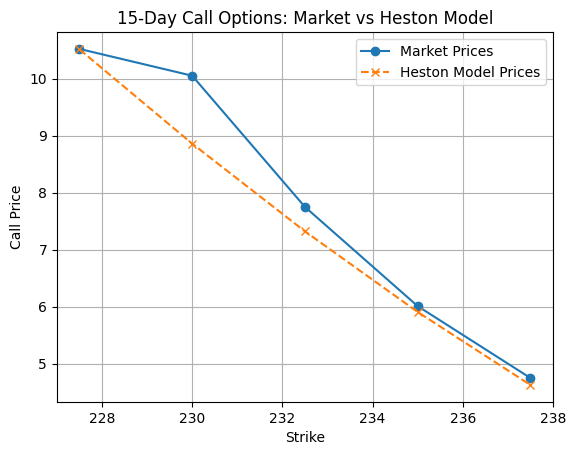

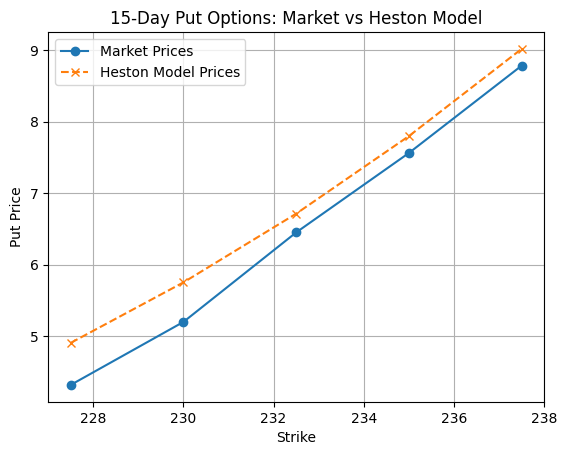

In [ ]:
# Market vs Model: CALLS
plt.figure()
plt.plot(
    df_15_calls["Strike"],
    df_15_calls["Price"],
    marker="o",
    linestyle="-",
    label="Market Prices"
)
plt.plot(
    df_15_calls["Strike"],
    df_15_calls["Model"],
    marker="x",
    linestyle="--",
    label="Heston Model Prices"
)

plt.xlabel("Strike")
plt.ylabel("Call Price")
plt.title("15-Day Call Options: Market vs Heston Model")
plt.legend()
plt.grid(True)
plt.show()


# Market vs Model: PUTS
plt.figure()
plt.plot(
    df_15_puts["Strike"],
    df_15_puts["Price"],
    marker="o",
    linestyle="-",
    label="Market Prices"
)
plt.plot(
    df_15_puts["Strike"],
    df_15_puts["Model"],
    marker="x",
    linestyle="--",
    label="Heston Model Prices"
)

plt.xlabel("Strike")
plt.ylabel("Put Price")
plt.title("15-Day Put Options: Market vs Heston Model")
plt.legend()
plt.grid(True)
plt.show()

**Step 1b - Carr-Madan Heston**

**Characteristic Function**

In [26]:
def heston_cf(u, T, kappa, theta, sigma, rho, v0, S0, r):
    i = 1j
    d = np.sqrt((rho*sigma*u*i - kappa)**2 + (sigma**2)*(u*i + u**2))
    g = (kappa - rho*sigma*u*i - d) / (kappa - rho*sigma*u*i + d)
    C = r*u*i*T + (kappa*theta)/(sigma**2) * ((kappa - rho*sigma*u*i - d)*T - 2*np.log((1-g*np.exp(-d*T))/(1-g)))
    D = ((kappa - rho*sigma*u*i - d)/(sigma**2)) * ((1-np.exp(-d*T))/(1-g*np.exp(-d*T)))
    return np.exp(C + D*v0 + i*u*np.log(S0))

**Carr–Madan call price with damping = 1.5**

In [27]:
def carr_madan_call_price(
    K, T, params,
    alpha=1.5,
    N=4096,
    B=1500
):
    kappa, theta, sigma, rho, v0 = params
    i = 1j

    eta = B / N
    u = np.arange(N) * eta

    beta = np.log(K)
    lambd = 2 * np.pi / (N * eta)

    cf_vals = heston_cf(
        u - (alpha + 1) * i,
        T, kappa, theta, sigma, rho, v0, S0, r
    )

    psi = (np.exp(-r * T) * cf_vals /
           (alpha**2 + alpha - u**2 + i * (2*alpha + 1) * u))

    integrand = np.exp(-i * u * beta) * psi * eta
    fft_vals = np.fft.fft(integrand).real

    j = int(beta / lambd)
    price = np.exp(-alpha * beta) / np.pi * fft_vals[j]

    # positivity enforcement
    return max(price, 0.0)


**Put via put–call parity**

In [28]:
def carr_madan_put_price(K, T, params):
    call = carr_madan_call_price(K, T, params)
    put = call - S0 + K * np.exp(-r * T)
    return max(put, 0.0)

**Calibration objective**

In [29]:
def objective(params):
    errors = []

    for _, row in df_15.iterrows():
        K = row["Strike"]
        T = row["T"]
        market_price = row["Price"]
        opt_type = row["Type"]

        if opt_type == "C":
            model_price = carr_madan_call_price(K, T, params)
        else:
            model_price = carr_madan_put_price(K, T, params)

        errors.append((market_price - model_price)**2)

    return np.mean(errors)

**Calibration**

In [30]:
# Initial guess and bounds
initial_guess = [2.0, 0.05, 0.5, -0.7, 0.04]
bounds = [
    (0.01, 10),     # kappa
    (0.001, 1),     # theta
    (0.01, 2),      # sigma
    (-0.99, -0.01), # rho
    (0.001, 1)      # v0
]

# Calibration
result = minimize(
    objective,
    initial_guess,
    bounds=bounds,
    method="L-BFGS-B"
)

params_calibrated = result.x
mse = result.fun

print("Calibrated parameters (Carr–Madan):")
print(
    f"kappa = {params_calibrated[0]:.6f}\n"
    f"theta = {params_calibrated[1]:.6f}\n"
    f"sigma = {params_calibrated[2]:.6f}\n"
    f"rho   = {params_calibrated[3]:.6f}\n"
    f"v0    = {params_calibrated[4]:.6f}"
)

print(f"\nMean Squared Error (MSE): {mse:.6f}")

Calibrated parameters (Carr–Madan):
kappa = 2.696974
theta = 1.000000
sigma = 0.010000
rho   = -0.010000
v0    = 1.000000

Mean Squared Error (MSE): 14.121330


**Compute Carr–Madan Model Prices**

In [31]:
df_15["Model"] = df_15.apply(
    lambda row: max(
        0.0,
        carr_madan_call_price(row["Strike"], row["T"], params_calibrated)
        if row["Type"] == "C"
        else carr_madan_put_price(row["Strike"], row["T"], params_calibrated)
    ),
    axis=1
)

# Split calls and puts
df_15_calls = df_15[df_15["Type"] == "C"].copy()
df_15_puts  = df_15[df_15["Type"] == "P"].copy()

print("Calls (Carr–Madan):")
print(df_15_calls[["Strike", "Price", "Model"]])

print("\nPuts (Carr–Madan):")
print(df_15_puts[["Strike", "Price", "Model"]])

Calls (Carr–Madan):
   Strike  Price     Model
0   227.5  10.52  4.201617
2   230.0  10.05  4.133299
4   232.5   7.75  4.066812
6   235.0   6.01  4.002089
8   237.5   4.75  3.939065

Puts (Carr–Madan):
   Strike  Price     Model
1   227.5   4.32  0.000000
3   230.0   5.20  1.026392
5   232.5   6.45  3.457656
7   235.0   7.56  5.890685
9   237.5   8.78  8.325411


/tmp/ipython-input-448751656.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_15["Model"] = df_15.apply(


**Market vs Model Plot (Call / Put)**

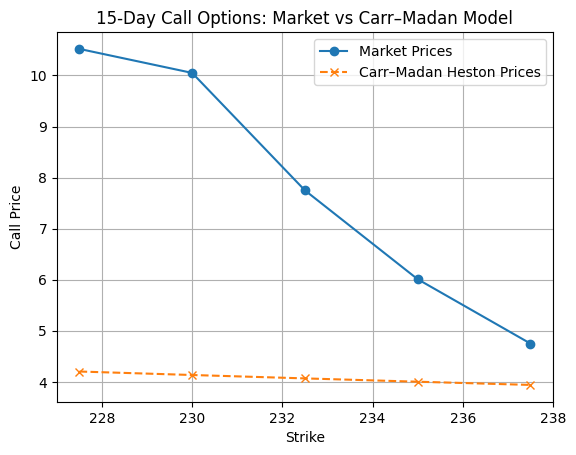

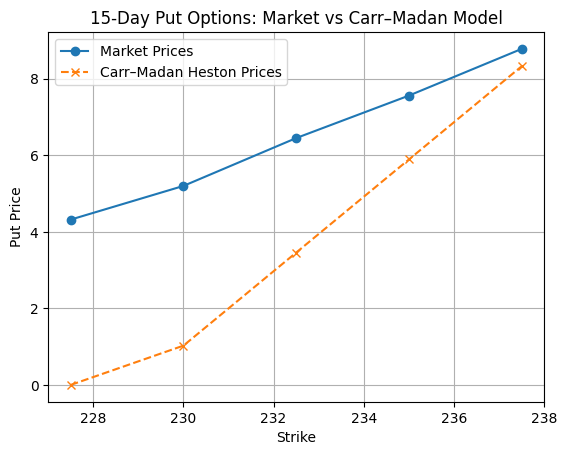

In [33]:
plt.figure()

plt.plot(
    df_15_calls["Strike"],
    df_15_calls["Price"],
    marker="o",
    linestyle="-",
    label="Market Prices"
)

plt.plot(
    df_15_calls["Strike"],
    df_15_calls["Model"],
    marker="x",
    linestyle="--",
    label="Carr–Madan Heston Prices"
)

plt.xlabel("Strike")
plt.ylabel("Call Price")
plt.title("15-Day Call Options: Market vs Carr–Madan Model")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()

plt.plot(
    df_15_puts["Strike"],
    df_15_puts["Price"],
    marker="o",
    linestyle="-",
    label="Market Prices"
)

plt.plot(
    df_15_puts["Strike"],
    df_15_puts["Model"],
    marker="x",
    linestyle="--",
    label="Carr–Madan Heston Prices"
)

plt.xlabel("Strike")
plt.ylabel("Put Price")
plt.title("15-Day Put Options: Market vs Carr–Madan Model")
plt.legend()
plt.grid(True)
plt.show()

**Step 1c**

**Asian Option Pricing Using Calibrated Parameter from Step 1a**

In [34]:
# Calibrated Heston parameters
kappa_v = 0.01
theta_v = 0.00249885
sigma_v = 1.19481584
rho     = -0.99
v0      = 0.1009912

S0 = 232.90
r = 0.015
trading_days_per_year = 250

# Market inputs
S0 = 232.90
r  = 0.015
T  = 20 / trading_days_per_year
K  = S0                           # ATM Asian call

# Monte Carlo controls
n_steps = 20                      # Daily monitoring
n_paths = 100_000                 # Large number for stability
seed = 42

**Heston Monte Carlo simulation (risk-neutral)**
- Using full truncation Euler, which preserves variance positivity.

In [35]:
def simulate_heston_paths(
    S0, v0, r, T,
    kappa, theta, sigma, rho,
    n_steps, n_paths, seed=42
):
    np.random.seed(seed)

    dt = T / n_steps
    S = np.zeros((n_paths, n_steps + 1))
    v = np.zeros((n_paths, n_steps + 1))

    S[:, 0] = S0
    v[:, 0] = v0

    Z1 = np.random.normal(size=(n_paths, n_steps))
    Z2 = np.random.normal(size=(n_paths, n_steps))
    W2 = rho * Z1 + np.sqrt(1 - rho**2) * Z2

    for t in range(n_steps):
        v_pos = np.maximum(v[:, t], 0.0)

        v[:, t + 1] = (
            v[:, t]
            + kappa * (theta - v_pos) * dt
            + sigma * np.sqrt(v_pos * dt) * W2[:, t]
        )

        v[:, t + 1] = np.maximum(v[:, t + 1], 0.0)

        S[:, t + 1] = (
            S[:, t]
            * np.exp(
                (r - 0.5 * v_pos) * dt
                + np.sqrt(v_pos * dt) * Z1[:, t]
            )
        )

    return S

**Asian call payoff and fair price - Using arithmetic average Asian call.**

In [38]:
def asian_call_price_mc(S0, K, r, T, kappa, theta, sigma, rho, v0, n_steps, n_paths, seed=42):
    S_paths = simulate_heston_paths(S0, v0, r, T, kappa, theta, sigma, rho, n_steps, n_paths, seed)
    S_avg = S_paths[:, 1:].mean(axis=1)  # exclude S0
    payoffs = np.maximum(S_avg - K, 0)
    discounted_payoff = np.exp(-r * T) * payoffs
    fair_price = discounted_payoff.mean()
    mc_error = discounted_payoff.std() / np.sqrt(n_paths)
    return fair_price, mc_error, S_paths, S_avg

**Compute fair price and client price (with 4% fee)**

In [39]:
fair_price, mc_error, S_paths, S_avg = asian_call_price_mc(
    S0, K, r, T,
    kappa_v, theta_v, sigma_v, rho, v0,
    n_steps, n_paths, seed
)

client_price = fair_price * 1.04

print(f"Asian Call Fair Price (MC): {fair_price:.4f}")
print(f"Monte Carlo Std Error: {mc_error:.6f}")
print(f"Client Price (4% fee): {client_price:.4f}")

Asian Call Fair Price (MC): 4.9672
Monte Carlo Std Error: 0.018830
Client Price (4% fee): 5.1659


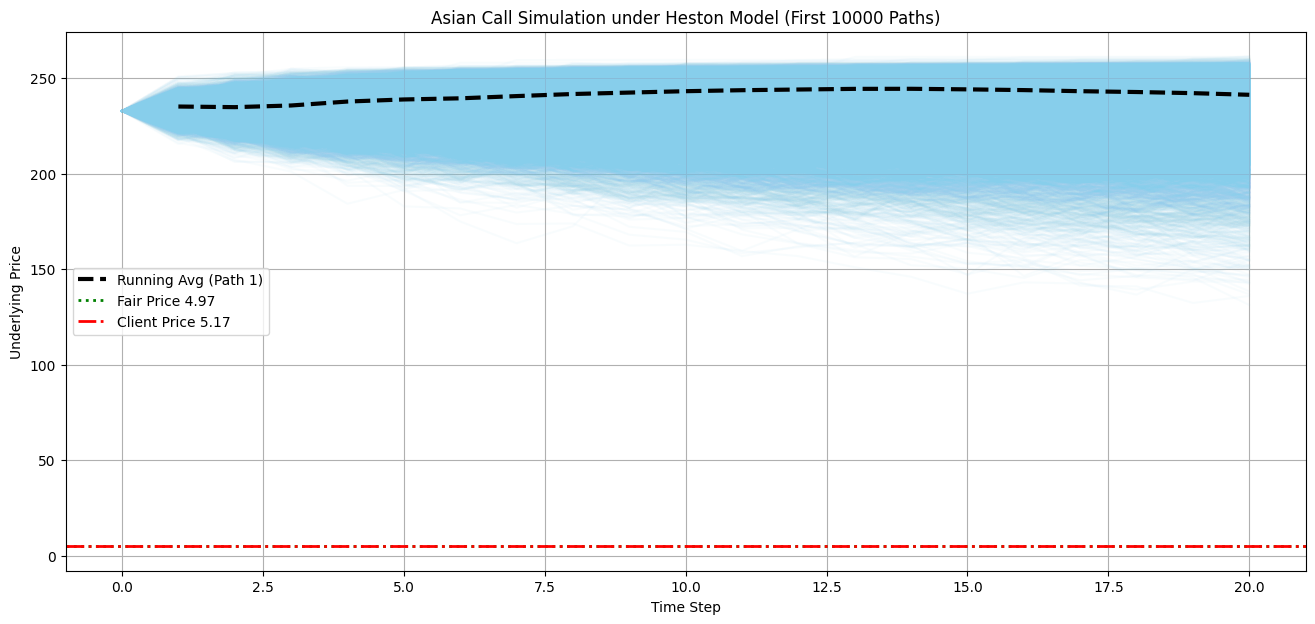

In [51]:
# Plotting first 1000 simulations
plt.figure(figsize=(16, 7))

# Plot first 1000 paths
for i in range(10000):
    plt.plot(range(n_steps + 1), S_paths[i], color='skyblue', alpha=0.05)

running_avg = np.cumsum(S_paths[0, 1:]) / np.arange(1, n_steps + 1)
plt.plot(range(1, n_steps + 1), running_avg, lw=3, color='black', linestyle='--', label='Running Avg (Path 1)')

plt.axhline(fair_price, color='green', linestyle=':', lw=2, label=f'Fair Price {fair_price:.2f}')
plt.axhline(client_price, color='red', linestyle='-.', lw=2, label=f'Client Price {client_price:.2f}')

plt.title("Asian Call Simulation under Heston Model (First 10000 Paths)")
plt.xlabel("Time Step")
plt.ylabel("Underlying Price")
plt.legend()
plt.grid(True)
plt.show()

**Step 2a - 60-days Maturity using Heston with Jumps (Bates, 1996) model**

In [53]:
S0 = 232.90
r = 0.015
trading_days = 250
T = 60 / trading_days

df_60 = df[df["Days to maturity"] == 60].copy()
df_60["T"] = T

df_60

,Days to maturity,Strike,Price,Type,T
10,60,227.5,16.78,C,0.24
11,60,227.5,11.03,P,0.24
12,60,230.0,17.65,C,0.24
13,60,230.0,12.15,P,0.24
14,60,232.5,16.86,C,0.24
15,60,232.5,13.37,P,0.24
16,60,235.0,16.05,C,0.24
17,60,235.0,14.75,P,0.24
18,60,237.5,15.10,C,0.24
19,60,237.5,15.62,P,0.24


In [54]:
def Heston_char_func(u, T, r, kappa_v, theta_v, sigma_v, rho, v0,
                    lambda_j=0, mu_j=0, sigma_j=0):
    """
    Bates model characteristic function (Heston + jumps)
    """
    # Heston part
    c1 = kappa_v * theta_v
    d = np.sqrt((rho * sigma_v * 1j * u - kappa_v)**2 + sigma_v**2 * (u * 1j + u**2))
    g = (kappa_v - rho * sigma_v * 1j * u - d) / (kappa_v - rho * sigma_v * 1j * u + d)

    H1 = 1j * u * r * T + (c1 / sigma_v**2) * ((kappa_v - rho * sigma_v * 1j * u - d) * T - 2*np.log((1 - g*np.exp(-d*T)) / (1 - g)))
    H2 = ((kappa_v - rho * sigma_v * 1j * u - d)/sigma_v**2) * ((1 - np.exp(-d*T)) / (1 - g*np.exp(-d*T)))

    char_val = np.exp(H1 + H2*v0)

    # Jump part
    if lambda_j > 0:
        jump_cf = np.exp(lambda_j * T * (np.exp(1j * u * mu_j - 0.5 * sigma_j**2 * u**2) - 1))
        char_val *= jump_cf

    return char_val

In [55]:
def Heston_int_func(u, S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0,
                    lambda_j=0, mu_j=0, sigma_j=0):
    cf = Heston_char_func(u - 0.5j, T, r, kappa_v, theta_v, sigma_v, rho, v0,
                          lambda_j, mu_j, sigma_j)
    integrand = (np.exp(1j * u * np.log(S0 / K)) * cf).real / (u**2 + 0.25)
    return integrand

def Heston_call_value(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0,
                      lambda_j=0, mu_j=0, sigma_j=0):
    integral = quad(lambda u: Heston_int_func(u, S0, K, T, r, kappa_v, theta_v,
                                              sigma_v, rho, v0, lambda_j, mu_j, sigma_j),
                    0, np.inf, limit=250)[0]
    call_price = max(0, S0 - np.exp(-r*T) * np.sqrt(S0*K) / np.pi * integral)
    return call_price

def Heston_put_value(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0,
                     lambda_j=0, mu_j=0, sigma_j=0):
    call = Heston_call_value(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0,
                             lambda_j, mu_j, sigma_j)
    put = call - S0 + K * np.exp(-r * T)
    return put

In [56]:
def calibration_error(params, df, S0, T, r):
    # Unpack parameters
    kappa_v, theta_v, sigma_v, rho, v0, lambda_j, mu_j, sigma_j = params

    # Penalize invalid params
    if theta_v < 0 or v0 < 0 or kappa_v < 0 or sigma_v < 0 or rho <= -1 or rho >= 1:
        return 1e6
    if lambda_j < 0 or sigma_j < 0 or abs(mu_j) > 1:
        return 1e6

    error = 0.0
    for _, row in df.iterrows():
        K = row['Strike']
        market_price = row['Price']
        if row['Type'] == 'C':
            model_price = Heston_call_value(S0, K, T, r, kappa_v, theta_v,
                                            sigma_v, rho, v0, lambda_j, mu_j, sigma_j)
        else:
            model_price = Heston_put_value(S0, K, T, r, kappa_v, theta_v,
                                           sigma_v, rho, v0, lambda_j, mu_j, sigma_j)
        error += (model_price - market_price)**2
    mse = error / len(df)
    return mse

In [57]:
initial_guess = [2.0, 0.05, 0.5, -0.7, 0.04, 0.1, 0.0, 0.1]  # kappa, theta, sigma, rho, v0, lambda, muJ, sigmaJ
bounds = [(0.01, 10), (0.001, 1), (0.01, 2), (-0.99, -0.01), (0.001, 1),
          (0.0, 5.0), (-0.2, 0.2), (0.001, 1.0)]

result = minimize(calibration_error, initial_guess, args=(df_60, S0, T, r),
                  bounds=bounds, method='Nelder-Mead', options={'maxiter': 2000})

print("Calibrated parameters (Bates model):", result.x)
print("Calibration MSE:", result.fun)

Calibrated parameters (Bates model): [ 9.16694612e-01  3.84456071e-01  1.30513207e-02 -1.00000000e-02
  1.00325290e-03  2.15682941e+00 -7.61550051e-02  1.00000000e-03]
Calibration MSE: 1.3792849586357652


In [61]:
params = result.x
kappa_v, theta_v, sigma_v, rho, v0, lambda_j, mu_j, sigma_j = params

df_60_calls = df_60[df_60['Type'] == 'C'].copy()
df_60_puts = df_60[df_60['Type'] == 'P'].copy()

df_60_calls['Model'] = df_60_calls.apply(
    lambda row: Heston_call_value(S0, row['Strike'], T, r, kappa_v, theta_v, sigma_v,
                                  rho, v0, lambda_j, mu_j, sigma_j), axis=1)
df_60_puts['Model'] = df_60_puts.apply(
    lambda row: Heston_put_value(S0, row['Strike'], T, r, kappa_v, theta_v, sigma_v,
                                 rho, v0, lambda_j, mu_j, sigma_j), axis=1)

print(df_60_calls)
print(df_60_puts)

    Days to maturity  Strike  Price Type     T      Model
10                60   227.5  16.78    C  0.24  17.505576
12                60   230.0  17.65    C  0.24  16.435922
14                60   232.5  16.86    C  0.24  15.461799
16                60   235.0  16.05    C  0.24  14.580079
18                60   237.5  15.10    C  0.24  13.786887
    Days to maturity  Strike  Price Type     T      Model
11                60   227.5  11.03    P  0.24  11.288048
13                60   230.0  12.15    P  0.24  12.709411
15                60   232.5  13.37    P  0.24  14.226304
17                60   235.0  14.75    P  0.24  15.835600
19                60   237.5  15.62    P  0.24  17.533424


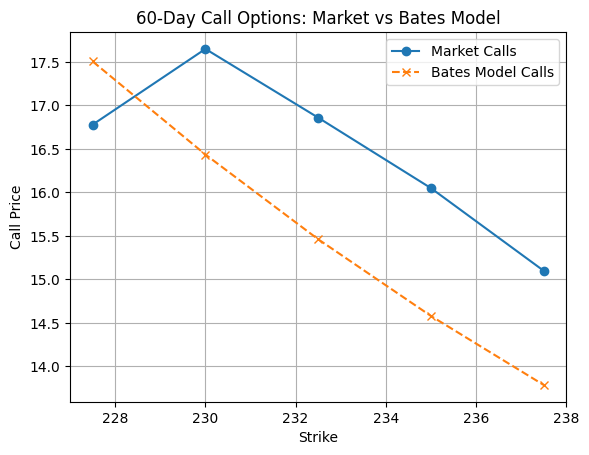

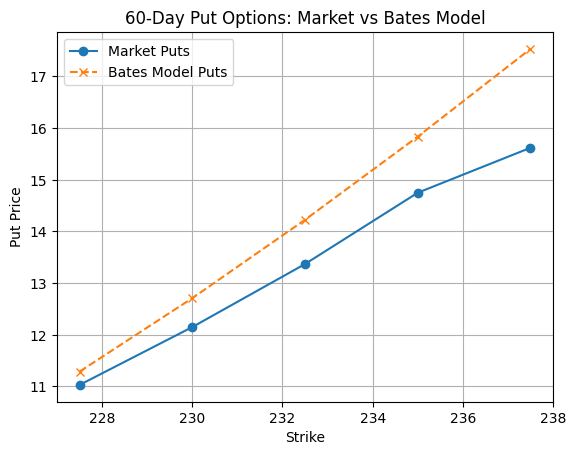

In [59]:
plt.figure()
plt.plot(df_60_calls["Strike"], df_60_calls["Price"], marker="o", linestyle="-", label="Market Calls")
plt.plot(df_60_calls["Strike"], df_60_calls["Model"], marker="x", linestyle="--", label="Bates Model Calls")
plt.xlabel("Strike")
plt.ylabel("Call Price")
plt.title("60-Day Call Options: Market vs Bates Model")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(df_60_puts["Strike"], df_60_puts["Price"], marker="o", linestyle="-", label="Market Puts")
plt.plot(df_60_puts["Strike"], df_60_puts["Model"], marker="x", linestyle="--", label="Bates Model Puts")
plt.xlabel("Strike")
plt.ylabel("Put Price")
plt.title("60-Day Put Options: Market vs Bates Model")
plt.legend()
plt.grid(True)
plt.show()

**Step 2b**

**Using Carr-Madan(1999) approach to Bates (1996) model for 60 days Maaturity**

In [ ]:
S0 = 232.90
r = 0.015
trading_days = 250
T = 60 / trading_days

df_60 = df[df["Days to maturity"] == 60].copy()
df_60["T"] = T

**Bates characteristic function**

In [ ]:
def bates_char_func(u, T, r,
                    kappa, theta, sigma, rho, v0,
                    lamb, muJ, sigmaJ):
    i = 1j

    # Jump compensator
    kJ = np.exp(muJ + 0.5 * sigmaJ**2) - 1

    d = np.sqrt(
        (rho * sigma * u * i - kappa)**2 +
        sigma**2 * (u * i + u**2)
    )

    g = (kappa - rho * sigma * u * i - d) / \
        (kappa - rho * sigma * u * i + d)

    C = (r - lamb * kJ) * u * i * T + \
        (kappa * theta / sigma**2) * (
            (kappa - rho * sigma * u * i - d) * T
            - 2 * np.log((1 - g * np.exp(-d * T)) / (1 - g))
        )

    D = ((kappa - rho * sigma * u * i - d) / sigma**2) * \
        ((1 - np.exp(-d * T)) / (1 - g * np.exp(-d * T)))

    jump_cf = np.exp(
        lamb * T * (np.exp(i * u * muJ - 0.5 * sigmaJ**2 * u**2) - 1)
    )

    return np.exp(C + D * v0) * jump_cf

**Carr–Madan call price (with damping α)**

In [ ]:
def carr_madan_call_bates(
    S0, K, T, r, params, alpha,
    Umax=150, N=4000
):
    kappa, theta, sigma, rho, v0, lamb, muJ, sigmaJ = params
    i = 1j

    u = np.linspace(1e-8, Umax, N)
    du = u[1] - u[0]

    cf = bates_char_func(
        u - (alpha + 1) * i,
        T, r,
        kappa, theta, sigma, rho, v0,
        lamb, muJ, sigmaJ
    )

    numerator = np.exp(-r * T) * cf
    denominator = alpha**2 + alpha - u**2 + i * (2 * alpha + 1) * u

    integrand = np.real(
        np.exp(-i * u * np.log(K)) * numerator / denominator
    )

    integral = np.trapz(integrand, u)
    call_price = (np.exp(-alpha * np.log(K)) / np.pi) * integral

    # Positivity enforcement
    return max(call_price, 0.0)

**Put prices via put–call parity**

In [ ]:
def carr_madan_put_from_call(
    S0, K, T, r, params, alpha
):
    call = carr_madan_call_bates(
        S0, K, T, r, params, alpha
    )
    put = call - S0 + K * np.exp(-r * T)
    return max(put, 0.0)

**Calibration Error (calls + puts)**

In [ ]:
def calibration_error_bates(
    params, df, alpha, S0, T, r
):
    kappa, theta, sigma, rho, v0, lamb, muJ, sigmaJ = params

    # Parameter validity
    if (
        kappa <= 0 or theta <= 0 or sigma <= 0 or
        v0 <= 0 or lamb < 0 or
        rho <= -0.99 or rho >= 0.99 or
        sigmaJ <= 0
    ):
        return 1e6

    error = 0.0
    n = 0

    for _, row in df.iterrows():
        K = row["Strike"]
        market = row["Price"]

        if row["Type"] == "C":
            model = carr_madan_call_bates(
                S0, K, T, r, params, alpha
            )
        else:
            model = carr_madan_put_from_call(
                S0, K, T, r, params, alpha
            )

        error += (model - market)**2
        n += 1

    return error / n

**α Sweep and Calibration**

In [ ]:
alpha_grid = [0.5, 0.75, 1.0, 1.25, 1.5]

initial_guess = [
    1.5,    # kappa
    0.05,   # theta
    0.4,    # sigma
    -0.6,   # rho
    0.05,   # v0
    0.2,    # lambda
    -0.05,  # muJ
    0.25    # sigmaJ
]

bounds = [
    (0.01, 5), (0.001, 1), (0.01, 1),
    (-0.95, 0.95), (0.001, 1),
    (0.0, 1), (-0.3, 0.1), (0.01, 1)
]

best_alpha = None
best_result = None
best_mse = np.inf

for alpha in alpha_grid:
    res = minimize(
        calibration_error_bates,
        initial_guess,
        args=(df_60, alpha, S0, T, r),
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": 500}
    )

    if res.fun < best_mse:
        best_mse = res.fun
        best_result = res
        best_alpha = alpha

print("Best alpha:", best_alpha)
print("Calibrated Bates parameters:", best_result.x)
print("MSE:", best_result.fun)

/tmp/ipython-input-1794809932.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(integrand, u)


Best alpha: 0.5
Calibrated Bates parameters: [ 1.5   0.05  0.4  -0.6   0.05  0.2  -0.05  0.25]
MSE: 213.40833841104026


In [ ]:
params = best_result.x

df_calls = df_60[df_60["Type"] == "C"].copy()
df_puts  = df_60[df_60["Type"] == "P"].copy()

df_calls["Model"] = df_calls["Strike"].apply(
    lambda K: carr_madan_call_bates(
        S0, K, T, r, params, best_alpha
    )
)

df_puts["Model"] = df_puts["Strike"].apply(
    lambda K: carr_madan_put_from_call(
        S0, K, T, r, params, best_alpha
    )
)

print("Calls:")
print(df_calls)

print("Puts:")
print(df_puts)

Calls:
    Days to maturity  Strike  Price Type     T  Model
10                60   227.5  16.78    C  0.24    0.0
12                60   230.0  17.65    C  0.24    0.0
14                60   232.5  16.86    C  0.24    0.0
16                60   235.0  16.05    C  0.24    0.0
18                60   237.5  15.10    C  0.24    0.0
Puts:
    Days to maturity  Strike  Price Type     T     Model
11                60   227.5  11.03    P  0.24  0.000000
13                60   230.0  12.15    P  0.24  0.000000
15                60   232.5  13.37    P  0.24  0.000000
17                60   235.0  14.75    P  0.24  1.255521
19                60   237.5  15.62    P  0.24  3.746537


/tmp/ipython-input-1794809932.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(integrand, u)
/tmp/ipython-input-1794809932.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(integrand, u)


**Market vs Model Price (Call and Put)**

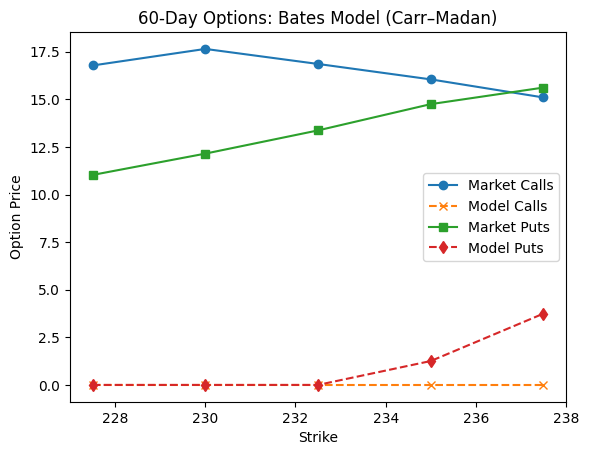

In [ ]:
plt.figure()
plt.plot(df_calls["Strike"], df_calls["Price"], "o-", label="Market Calls")
plt.plot(df_calls["Strike"], df_calls["Model"], "x--", label="Model Calls")
plt.plot(df_puts["Strike"], df_puts["Price"], "s-", label="Market Puts")
plt.plot(df_puts["Strike"], df_puts["Model"], "d--", label="Model Puts")
plt.xlabel("Strike")
plt.ylabel("Option Price")
plt.title("60-Day Options: Bates Model (Carr–Madan)")
plt.legend()
plt.show()

**Step 2c**

In [62]:
# Parameters
S0 = 232.90
K = 0.95 * S0
r = 0.015
T = 70 / 250
n_steps = 70
n_paths = 100_000
seed = 42

# Calibrated Bates parameters
kappa_v = 0.917
theta_v = 0.384
sigma_v = 0.0131
rho     = -0.01
v0      = 0.001
lambda_j = 2.157
mu_j     = -0.076
sigma_j  = 0.001

In [63]:
def simulate_bates_paths(S0, v0, r, T, kappa, theta, sigma, rho,
                         lambda_j, mu_j, sigma_j, n_steps, n_paths, seed=42):
    np.random.seed(seed)
    dt = T / n_steps

    S = np.zeros((n_paths, n_steps + 1))
    v = np.zeros((n_paths, n_steps + 1))

    S[:,0] = S0
    v[:,0] = v0

    Z1 = np.random.normal(size=(n_paths, n_steps))
    Z2 = np.random.normal(size=(n_paths, n_steps))
    W2 = rho * Z1 + np.sqrt(1 - rho**2) * Z2

    # Jump Poisson
    jumps = np.random.poisson(lambda_j * dt, size=(n_paths, n_steps))

    for t in range(n_steps):
        v_pos = np.maximum(v[:, t], 0.0)
        # Heston variance update
        v[:, t+1] = v[:, t] + kappa * (theta - v_pos) * dt + sigma * np.sqrt(v_pos*dt) * W2[:, t]
        v[:, t+1] = np.maximum(v[:, t+1], 0.0)
        # Asset price update with jumps
        S[:, t+1] = S[:, t] * np.exp((r - 0.5*v_pos)*dt + np.sqrt(v_pos*dt)*Z1[:, t] + jumps[:,t]*mu_j)

    return S

In [64]:
# Simulate paths
S_paths = simulate_bates_paths(S0, v0, r, T, kappa_v, theta_v, sigma_v, rho,
                               lambda_j, mu_j, sigma_j, n_steps, n_paths, seed)

# Payoff and fair price
payoffs = np.maximum(K - S_paths[:,-1], 0)
fair_price = np.exp(-r*T) * np.mean(payoffs)
client_price = fair_price * 1.04

print(f"European Put Fair Price (MC): {fair_price:.4f}")
print(f"Client Price (4% fee): {client_price:.4f}")

European Put Fair Price (MC): 9.9963
Client Price (4% fee): 10.3962


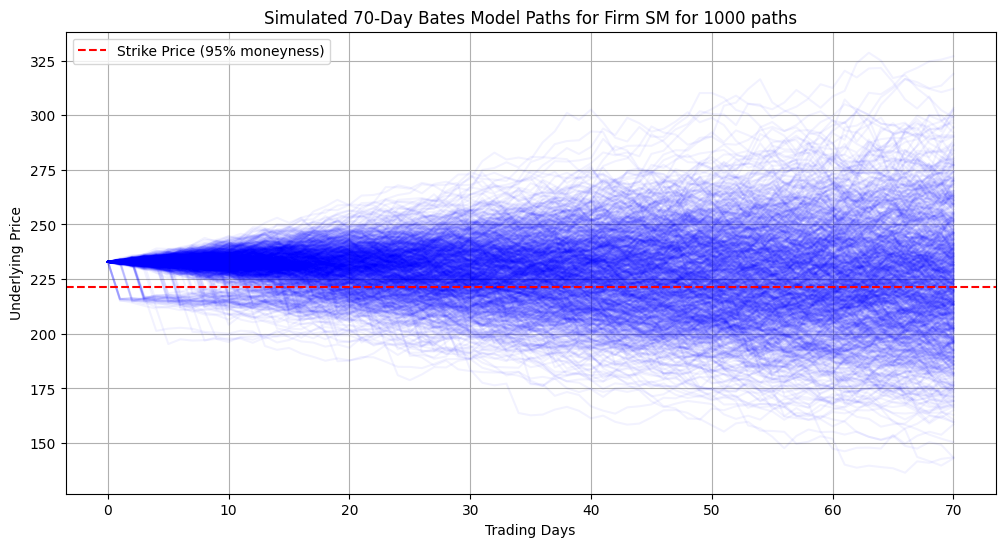

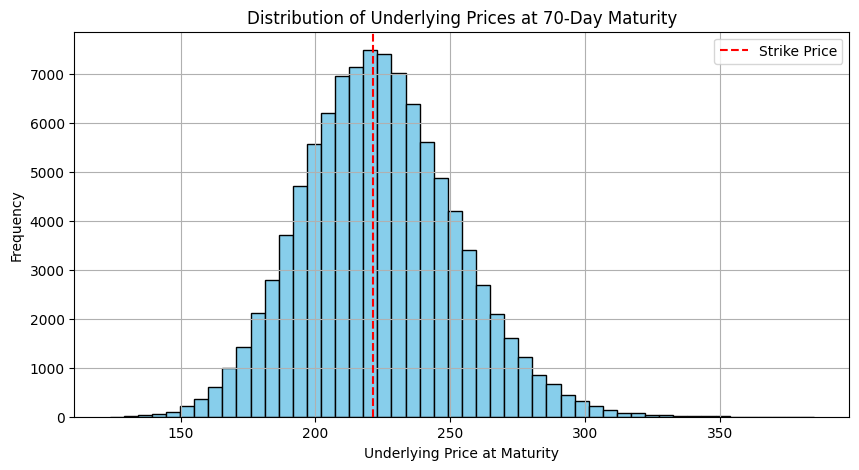

In [68]:
# Plot simulated paths
plt.figure(figsize=(12,6))
for i in range(1000):  # plot only first 1000 paths for clarity
    plt.plot(S_paths[i], color='blue', alpha=0.05)

plt.axhline(K, color='red', linestyle='--', label='Strike Price (95% moneyness)')
plt.xlabel("Trading Days")
plt.ylabel("Underlying Price")
plt.title("Simulated 70-Day Bates Model Paths for Firm SM for 1000 paths")
plt.legend()
plt.grid(True)
plt.show()


# Plot histogram of terminal prices
plt.figure(figsize=(10,5))
plt.hist(S_paths[:,-1], bins=50, color='skyblue', edgecolor='black')
plt.axvline(K, color='red', linestyle='--', label='Strike Price')
plt.xlabel("Underlying Price at Maturity")
plt.ylabel("Frequency")
plt.title("Distribution of Underlying Prices at 70-Day Maturity")
plt.legend()
plt.grid(True)
plt.show()

**Step 3a**

**Euribor Term structure using a Cox–Ingersoll–Ross (CIR, 1985) Short-rate model**

In [ ]:
from scipy.interpolate import CubicSpline
from scipy.optimize import minimize

In [ ]:
# Euribor market data
maturities = np.array([1/52, 1/12, 3/12, 6/12, 1.0])  # in years
rates = np.array([0.00648, 0.00679, 0.01173, 0.01809, 0.02556])

# Initial short rate
r0 = rates[0]

# Cubic spline interpolation (weekly)
weeks = np.linspace(1/52, 1.0, 52)
spline = CubicSpline(maturities, rates)
interp_rates = spline(weeks)

In [ ]:
# CIR zero-coupon bond functions

def cir_zero_coupon(T, r0, kappa, theta, sigma):
    gamma = np.sqrt(kappa**2 + 2 * sigma**2)
    numerator = 2 * gamma * np.exp((kappa + gamma) * T / 2)
    denominator = (
        2 * gamma + (kappa + gamma) * (np.exp(gamma * T) - 1)
    )
    A = (numerator / denominator) ** (2 * kappa * theta / sigma**2)
    B = 2 * (np.exp(gamma * T) - 1) / denominator
    return A * np.exp(-B * r0)

def cir_zero_rate(T, r0, kappa, theta, sigma):
    P = cir_zero_coupon(T, r0, kappa, theta, sigma)
    return -np.log(P) / T

In [ ]:
# Calibration objective

def cir_mse(params):
    kappa, theta, sigma = params
    if kappa <= 0 or theta <= 0 or sigma <= 0:
        return 1e6
    model_rates = np.array([
        cir_zero_rate(T, r0, kappa, theta, sigma) for T in weeks
    ])
    return np.mean((model_rates - interp_rates)**2)

In [ ]:
# Optimization

initial_guess = [0.5, 0.02, 0.05]
bounds = [(0.01, 5.0), (0.001, 0.1), (0.001, 0.5)]

result = minimize(cir_mse, initial_guess, bounds=bounds, method="L-BFGS-B")

kappa_hat, theta_hat, sigma_hat = result.x

print("Calibrated CIR parameters:")
print(f"kappa = {kappa_hat:.4f}")
print(f"theta = {theta_hat:.4f}")
print(f"sigma = {sigma_hat:.4f}")
print(f"MSE   = {result.fun:.6e}")

Calibrated CIR parameters:
kappa = 0.5119
theta = 0.0973
sigma = 0.0500
MSE   = 6.440968e-07


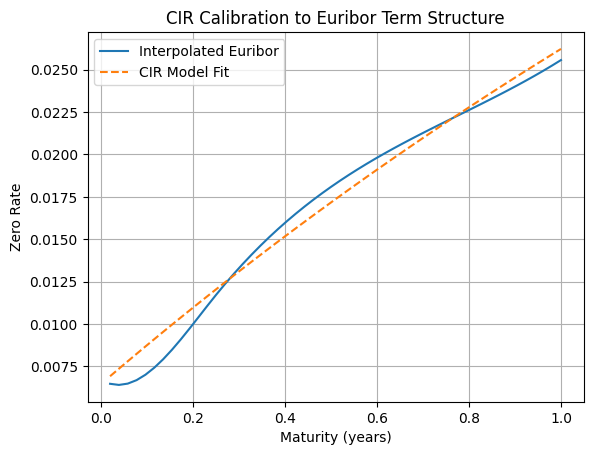

In [ ]:
# Model vs market plot

cir_fitted = np.array([
    cir_zero_rate(T, r0, kappa_hat, theta_hat, sigma_hat) for T in weeks
])

plt.figure()
plt.plot(weeks, interp_rates, label="Interpolated Euribor", linestyle="-")
plt.plot(weeks, cir_fitted, label="CIR Model Fit", linestyle="--")
plt.xlabel("Maturity (years)")
plt.ylabel("Zero Rate")
plt.title("CIR Calibration to Euribor Term Structure")
plt.legend()
plt.grid(True)
plt.show()

**Step 3b**

**CIR Monte Carlo Simulation of 12-Month Euribor**

In [ ]:
# Calibrated CIR parameters (from previous step)

kappa = 0.5119
theta = 0.0973
sigma = 0.0500

# Current 12M Euribor (market)
r0 = 0.02556   # 2.556%

T = 1.0
n_steps = 252
dt = T / n_steps
n_sims = 100_000

np.random.seed(42)

In [ ]:
# CIR simulation (Full Truncation Euler Scheme)

rates = np.zeros((n_sims, n_steps + 1))
rates[:, 0] = r0

for t in range(1, n_steps + 1):
    z = np.random.normal(0.0, 1.0, n_sims)
    r_prev = np.maximum(rates[:, t - 1], 0.0)

    dr = (
        kappa * (theta - r_prev) * dt
        + sigma * np.sqrt(r_prev) * np.sqrt(dt) * z
    )

    rates[:, t] = np.maximum(r_prev + dr, 0.0)

# Terminal 12M Euribor after 1 year
r_T = rates[:, -1]

In [ ]:
# Monte Carlo statistics
expected_rate = np.mean(r_T)
lower_95 = np.percentile(r_T, 2.5)
upper_95 = np.percentile(r_T, 97.5)

print("Monte Carlo results for 12M Euribor in 1 year")
print(f"Expected value      : {expected_rate:.4%}")
print(f"95% confidence min  : {lower_95:.4%}")
print(f"95% confidence max  : {upper_95:.4%}")

Monte Carlo results for 12M Euribor in 1 year
Expected value      : 5.4315%
95% confidence min  : 3.9258%
95% confidence max  : 7.1517%


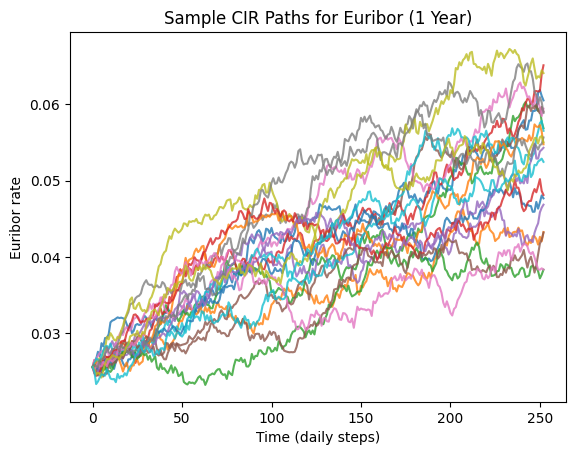

In [ ]:
# Plot simulated sample paths
plt.figure()
for i in range(20):
    plt.plot(rates[i], alpha=0.8)

plt.title("Sample CIR Paths for Euribor (1 Year)")
plt.xlabel("Time (daily steps)")
plt.ylabel("Euribor rate")
plt.show()

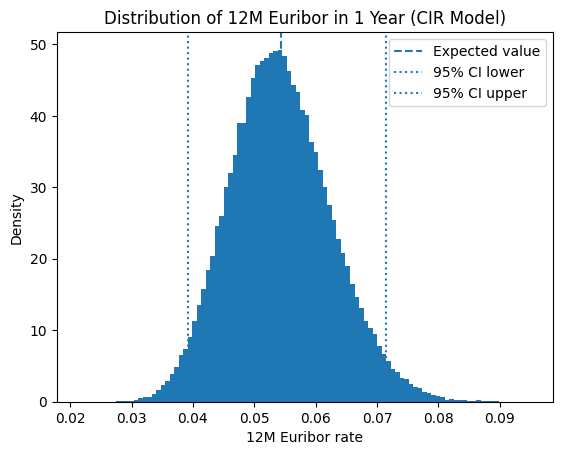

In [ ]:
# Plot terminal distribution
plt.figure()
plt.hist(r_T, bins=100, density=True)
plt.axvline(expected_rate, linestyle='--', label="Expected value")
plt.axvline(lower_95, linestyle=':', label="95% CI lower")
plt.axvline(upper_95, linestyle=':', label="95% CI upper")
plt.title("Distribution of 12M Euribor in 1 Year (CIR Model)")
plt.xlabel("12M Euribor rate")
plt.ylabel("Density")
plt.legend()
plt.show()